# Object Detection using YOLO

In this final blog of the series of projects, we will be shifting focus from OpenCV to the current standard algorithm in real-time object detection, namely, YOLO, or You-Only-Look-Once.

In [ ]:
# @title Contact Software Sushi {"display-mode":"form"}
import base64
import requests
import urllib.request
from IPython.display import display, HTML

image_url = "https://raw.githubusercontent.com/SoftwareSushi/marketing-resources/main/images/company/logo.png"
with urllib.request.urlopen(image_url) as response:
    image_data = response.read()
    encoded_image = base64.b64encode(image_data).decode()

def load_html_from_github(raw_url):
    response = requests.get(raw_url)
    html_content = response.text
    updated_html = html_content.replace('../images/logo.png', f"data:image/png;base64, {encoded_image}")
    display(HTML(updated_html))

load_html_from_github('https://raw.githubusercontent.com/SoftwareSushi/marketing-resources/refs/heads/main/html/cta-banner-with-logo.html')

### Imports

In [ ]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 20.1 MB/s eta 0:00:00


In [ ]:
import cv2
import numpy as np
import urllib.request
import matplotlib.pyplot as plt

from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
# Run this cell if running from the Google Colab notebook

# Collecting the custom dataset
# Open the temporary files on the left side bar to ensure that the only files
# present are sample_data and fish_dataset.v4-fish-v4.yolov11

!git clone --depth 1 https://github.com/SoftwareSushi/marketing-resources.git
!cp -r marketing-resources/images/YOLO/fish_dataset.v4-fish-v4.yolov11 .
!rm -rf marketing-resources

Cloning into 'marketing-resources'...
remote: Enumerating objects: 1373, done.
remote: Counting objects: 100% (1373/1373), done.
remote: Compressing objects: 100% (779/779), done.
remote: Total 1373 (delta 3), reused 1366 (delta 3), pack-reused 0 (from 0)
Receiving objects: 100% (1373/1373), 146.78 MiB | 42.14 MiB/s, done.
Resolving deltas: 100% (3/3), done.


In [ ]:
# Run this cell if running locally

# Collecting the custom dataset
import os
import shutil
from git import Repo

# Clone the repository
repo_url = "https://github.com/SoftwareSushi/marketing-resources.git"
repo_dir = "marketing-resources"
if not os.path.exists(repo_dir):
    Repo.clone_from(repo_url, repo_dir)

# Copy the required file
source_file = "marketing-resources/images/YOLO/fish_dataset.v4-fish-v4.yolov11"
destination_file = "fish_dataset.v4-fish-v4.yolov11"
if os.path.isdir(source_file):
    shutil.copytree(source_file, destination_file)

### Utils

In [ ]:
# Function for the creation of flexible MatPlotLib figures
def create_mpl_figure(w,h,images,titles="Image",axis="off",color_maps=None):
    plt.figure(figsize=[w,h])

    for i, image in enumerate(images):
        plt.subplot(1,len(images),i+1);

        if color_maps is None:
            plt.imshow(image);
        elif len(color_maps) > 1:
            plt.imshow(image, cmap=f"{color_maps[i]}");
        else:
            plt.imshow(image, cmap=f"{color_maps[0]}")

        plt.title(titles[i]);
        plt.axis(axis);

## Training and Detecting our Custom Class

Where in the previous blogs we went over OpenCV's techniques for facial detection particularly, using YOLO, we will now be able detect anything we would want to, provided we have the necessary dataset to train the model on. In this case, we will be utilizing a custom dataset containing all the necessary training, testing, and validation images in the proper format for YOLOv11.

If you want to make your own dataset, I would recommend utilizing the free features available to you on Roboflow. [This video](https://www.youtube.com/watch?v=a3SBRtILjPI&t=223s) is a huge help for determining how to go through the annotation process. For sourcing images for your dataset, [Kaggle](https://www.kaggle.com/datasets?tags=13207-Computer+Vision) is a great help! Make sure you cite your sources if using your dataset in a work you plan on publishing.

## Use Cases

YOLO is used even more frequently than the previous techniques we reviewed. It has become the standard in real-time object detection, thanks to its incredible speed, which is continually increasing as it is improved year after year. Be it faces, or cars, or any thing else that a user may want to detect, YOLO presents the tools for doing such things, and doing them quickly and efficiently, provided the user can supply it with a properly structured dataset.

## Training the Model

Compared to the amount of pre-processing and extra steps that were required when utilizing OpenCV, another advantage of YOLO becomes abundantly clear during implementation, namely how simple the entire pipeline is, from training to prediction. In the following code, we provide YOLO with out dataset, and it handles all the training. Because we are running 50 training epochs, it will run for roughly 9-12 minutes thanks to the GPU we are utilizing for this runtime. After that point, we will be able to move on.

**It is very important to note before moving forward that if you plan on training on your local machine, be aware that without a compatible graphics card, CUDA, and PyTorch installed, the training process will default to using your CPU, which will take a number of hours to complete, as opposed to taking under thirty minutes using a GPU. Proceed with caution if you have not installed these things and verified that PyTorch is detecting your GPU.**

In [ ]:
# If you are running locally and want to verify your PyTorch and CUDA installation, run this cell
# If this returns "True", you are good to go
# If this returns "False", verify your installation of PyTorch and CUDA

import torch
print(torch.cuda.is_available())

In [ ]:
# Load a model
model = YOLO("yolo11s.pt")  # load a pretrained model (recommended for training)

# Train the model
training = model.train(data="/content/fish_dataset.v4-fish-v4.yolov11/data.yaml", epochs=50, imgsz=640)

# If you are running this with a GPU, you will need to add the following line to the above code after the imgsz parameter: device=0

Ultralytics 8.3.193 🚀 Python-3.12.11 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/fish_dataset.v4-fish-v4.yolov11/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True

## Viewing Training Results

After running the training process, a number of different things are saved, presenting us with how the training process went. The most important of these is stored within the results.png image. Provided the training is going according to plan, what we should observe is an inverse relationship between the different types of loss and minimum average precision and recall.

My result is saved after training, but ensure you run this code after doing the training process to review your own results before continuing. Additionally, the path to the results image may change after training on your end, so verify in the previous code block where your results are saved to.

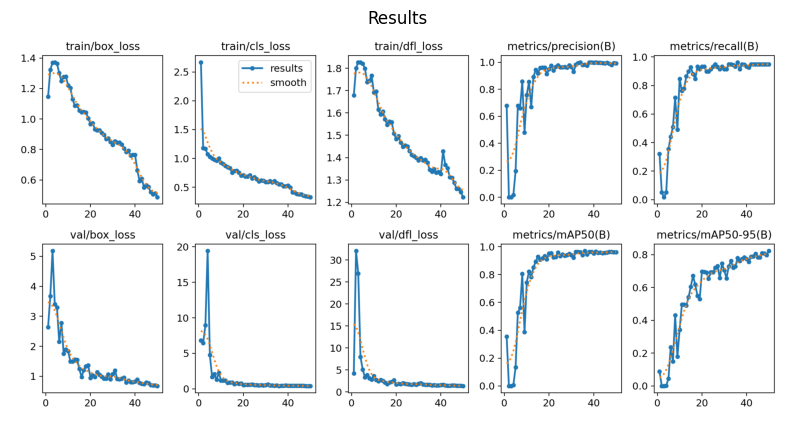

In [ ]:
image = plt.imread("/content/runs/detect/train2/results.png")

# Display the results image
create_mpl_figure(10,10, [image], ["Results"])

## Predicting the Custom Class on Test Images

Now that the model has been trained, and the results of its training have been observed to be reliable, we can now going about actually testing its ability to detect the class on which it was trained, which is in this case, fish.

In similar fashion to the displaying of the results image, ensure that the path to the image is correct after running the prediction. You may need to change the path for the pred_test variable according to wherever the results are saved.

In [ ]:
# Run the model against a test image, verifying that it properly identifies the custom class
prediction = model("/content/fish_dataset.v4-fish-v4.yolov11/test/images/P1ROZC-Z_7_jpg.rf.745f9956e192bf19ef2ebd8a7ede9d26.jpg", save=True)


image 1/1 /content/fish_dataset.v4-fish-v4.yolov11/test/images/P1ROZC-Z_7_jpg.rf.745f9956e192bf19ef2ebd8a7ede9d26.jpg: 640x640 1 fish, 15.9ms
Speed: 2.3ms preprocess, 15.9ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/train23


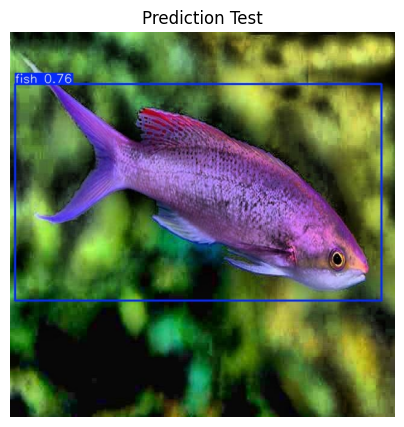

In [ ]:
pred_test = plt.imread("/content/runs/detect/train23/P1ROZC-Z_7_jpg.rf.745f9956e192bf19ef2ebd8a7ede9d26.jpg")

# Display the test image after it is fed through the Model
create_mpl_figure(5,5, [pred_test], ["Prediction Test"])

## Conclusion

And just like that, you are able to detect custom objects using the YOLO algorithm! Not only is it exceedingly fast, but it is very easy to implement and train custom models on!

In [ ]:
# @title Contact Software Sushi
load_html_from_github('https://raw.githubusercontent.com/SoftwareSushi/marketing-resources/refs/heads/main/html/cta-banner.html')